## Astronomía Observacional
## Astropy, Tutorial 3: Reducción de datos espectroscópicos, parte 3: Extracción del espectro final calibrado en longitud de onda
María Alejandra Moreno, Cesar Mauricio Mendoza

Este tutorial, el tercero de una serie, muestra cómo aplicar una solución de traza y longitud de onda a datos científicos. A continuación, muestra cómo realizar análisis básicos, es decir, el ajuste de líneas.

## Extraer el espectro científico

Primero, repetimos el proceso de rastreo y extracción derivado en la Parte 1, pero ahora para Deneb:

In [2]:
from PIL import Image as PILImage
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('dark_background')

In [3]:
from astropy.modeling.models import Linear1D
from astropy import constants
from astropy import units as u
from astropy.visualization import quantity_support
quantity_support()

<astropy.visualization.units.quantity_support.<locals>.MplQuantityConverter at 0x7fef01a2aa90>

In [4]:
import numpy as np
from PIL import Image as PILImage
image_array_2 = np.array(PILImage.open('deneb_3s_13.63g_1.bmp'))
image_array_1 = np.array(PILImage.open("aldebaran_3s_1.bmp"))
image_array_3 = np.array(PILImage.open("vega_2.jpeg").convert("L"))
image_array_4 = np.array(PILImage.open("Sol.png").convert("L"))

In [5]:
from astropy.modeling.polynomial import Polynomial1D
from astropy.modeling.models import Gaussian1D
from astropy.modeling.fitting import LevMarLSQFitter, LinearLSQFitter
linfitter = LinearLSQFitter()

In [6]:
yaxis2 = np.repeat(np.arange(470, 520)[:,None], image_array_2.shape[1], axis=1)
xvals2 = np.arange(image_array_2.shape[1])
weighted_yaxis_values2 = np.average(yaxis2, axis=0, weights=image_array_2[470:520,:] - np.median(image_array_2))
polymodel2 = Polynomial1D(degree=3)
fitted_polymodel2 = linfitter(polymodel2, xvals2, weighted_yaxis_values2)
trace_center2 = fitted_polymodel2(xvals2)

yaxis1 = np.repeat(np.arange(410, 520)[:,None], image_array_1.shape[1], axis=1)
xvals1 = np.arange(image_array_1.shape[1])
weighted_yaxis_values1 = np.average(yaxis1, axis=0, weights=image_array_1[410:520,:] - np.median(image_array_1))
polymodel1 = Polynomial1D(degree=3)
fitted_polymodel1 = linfitter(polymodel1, xvals1, weighted_yaxis_values1)
trace_center1 = fitted_polymodel1(xvals1)

yaxis3 = np.repeat(np.arange(200, 360)[:,None], image_array_3.shape[1], axis=1)
xvals3 = np.arange(image_array_3.shape[1])
weighted_yaxis_values3 = np.average(yaxis3, axis=0, weights=image_array_3[200:360,:] - np.median(image_array_3))
polymodel3 = Polynomial1D(degree=3)
fitted_polymodel3 = linfitter(polymodel3, xvals3, weighted_yaxis_values3)
trace_center3 = fitted_polymodel3(xvals3)

yaxis4 = np.repeat(np.arange(490, 710)[:,None], image_array_4.shape[1], axis=1)
xvals4 = np.arange(image_array_4.shape[1])
weighted_yaxis_values4 = np.average(yaxis4, axis=0, weights=image_array_4[490:710,:] - np.median(image_array_4))
polymodel4 = Polynomial1D(degree=3)
fitted_polymodel4 = linfitter(polymodel4, xvals4, weighted_yaxis_values4)
trace_center4 = fitted_polymodel4(xvals4)



In [7]:
npixels_to_cut = 15
trace_center2 = fitted_polymodel2(xvals2)
cutouts2 = np.array([image_array_2[int(yval)-npixels_to_cut:int(yval)+npixels_to_cut, ii]
                    for yval, ii in zip(trace_center2, xvals2)])
cutouts2.shape
mean_trace_profile2 = cutouts2.mean(axis=0)

npixels_to_cut = 15
trace_center1 = fitted_polymodel1(xvals1)
cutouts1 = np.array([image_array_1[int(yval)-npixels_to_cut:int(yval)+npixels_to_cut, ii]
                    for yval, ii in zip(trace_center1, xvals1)])
cutouts1.shape
mean_trace_profile1 = cutouts1.mean(axis=0)

npixels_to_cut = 15
trace_center3 = fitted_polymodel3(xvals3)
cutouts3 = np.array([image_array_3[int(yval)-npixels_to_cut:int(yval)+npixels_to_cut, ii]
                    for yval, ii in zip(trace_center3, xvals3)])
cutouts3.shape
mean_trace_profile3 = cutouts3.mean(axis=0)

npixels_to_cut = 15
trace_center4 = fitted_polymodel4(xvals4)
cutouts4 = np.array([image_array_4[int(yval)-npixels_to_cut:int(yval)+npixels_to_cut, ii]
                    for yval, ii in zip(trace_center4, xvals4)])
cutouts4.shape
mean_trace_profile4 = cutouts4.mean(axis=0)


In [8]:
spectrum2 = np.array([np.average(image_array_2[int(yval)-npixels_to_cut:int(yval)+npixels_to_cut, ii],
                                weights=mean_trace_profile2)
                     for yval, ii in zip(trace_center2, xvals2)])

spectrum1 = np.array([np.average(image_array_1[int(yval)-npixels_to_cut:int(yval)+npixels_to_cut, ii],
                                weights=mean_trace_profile1)
                     for yval, ii in zip(trace_center1, xvals1)])

spectrum3 = np.array([np.average(image_array_3[int(yval)-npixels_to_cut:int(yval)+npixels_to_cut, ii],
                                weights=mean_trace_profile3)
                     for yval, ii in zip(trace_center3, xvals3)])

spectrum4 = np.array([np.average(image_array_4[int(yval)-npixels_to_cut:int(yval)+npixels_to_cut, ii],
                                weights=mean_trace_profile4)
                     for yval, ii in zip(trace_center4, xvals4)])

Luego recuperamos la solución de longitud de onda derivada en la Parte 2.

In [9]:
wlmodel = Linear1D(slope=-0.10213643, intercept=562.3862495)

In [10]:
wavelengths2 = wlmodel(xvals2) * u.nm
wavelengths1 = wlmodel(xvals1) * u.nm
wavelengths3 = wlmodel(xvals3) * u.nm
wavelengths4 = wlmodel(xvals4) * u.nm

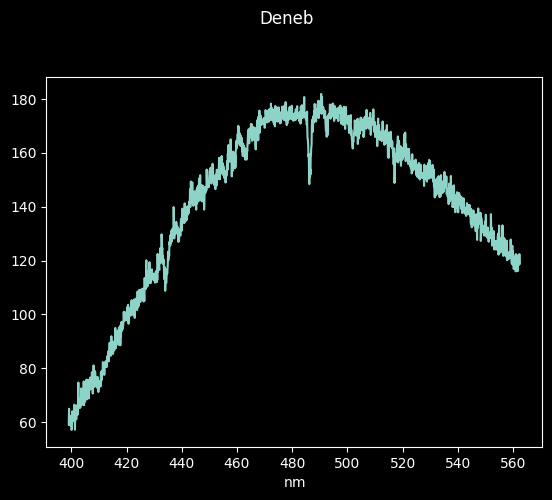

In [11]:
plt.suptitle("Deneb", y=1.02)
plt.plot(wavelengths2, spectrum2)


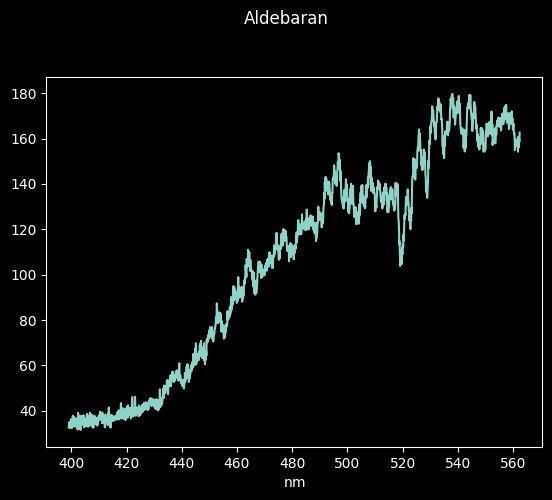

In [12]:
plt.suptitle("Aldebaran", y=1.02)
plt.plot(wavelengths1, spectrum1)

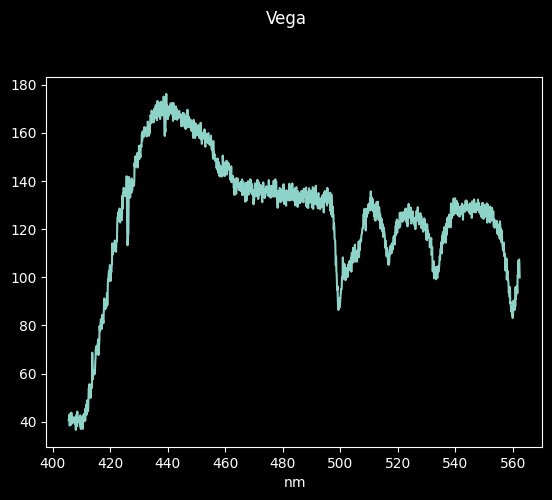

In [13]:
plt.suptitle("Vega", y=1.02)
plt.plot(wavelengths3, spectrum3)

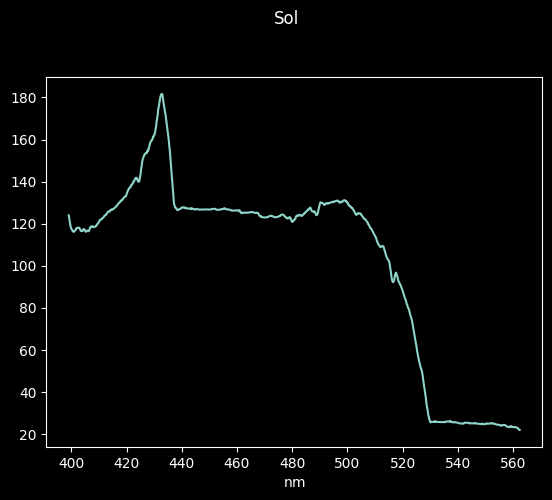

In [14]:
plt.suptitle("Sol", y=1.02)
plt.plot(wavelengths4, spectrum4)

# Análisis

Ahora, realizaremos un análisis básico de nuestro espectro completamente extraído y calibrado en longitud de onda.

Nosotros acercamos la línea 4860 Angstrom - H-Beta de Deneb


(np.float64(470.0), np.float64(510.0), np.float64(140.0), np.float64(190.0))

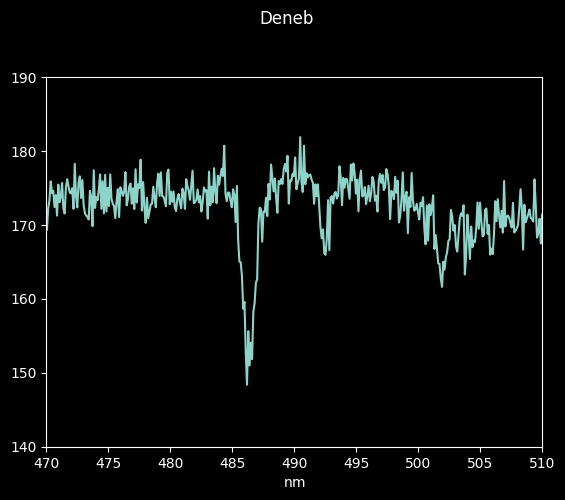

In [15]:
plt.suptitle("Deneb", y=1.02)
plt.plot(wavelengths2, spectrum2)
plt.axis([470,510,140,190])

(np.float64(510.0), np.float64(530.0), np.float64(100.0), np.float64(170.0))

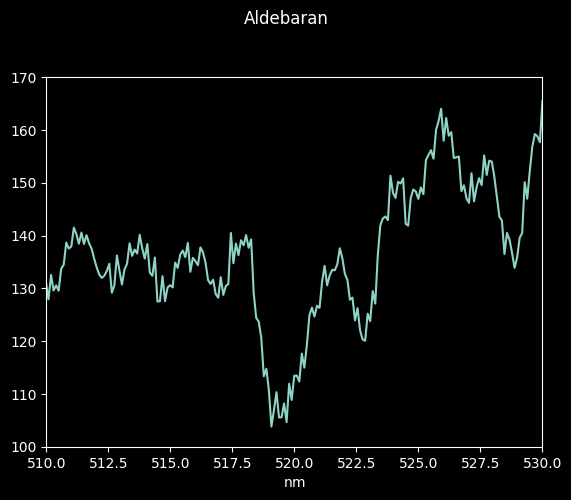

In [16]:
plt.suptitle("Aldebaran", y=1.02)
plt.plot(wavelengths1, spectrum1)
plt.axis([510,530,100,170])

(np.float64(520.0), np.float64(550.0), np.float64(90.0), np.float64(150.0))

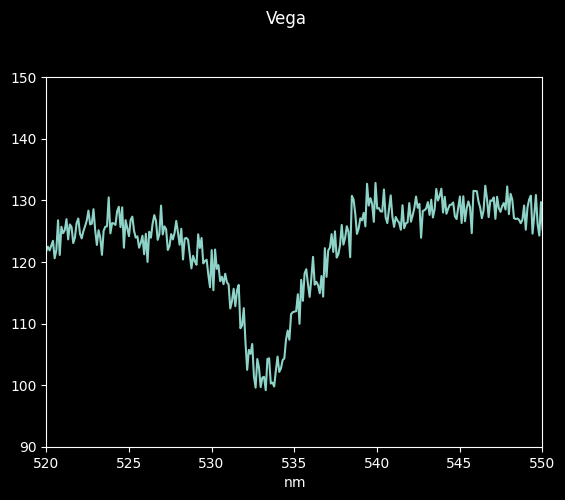

In [17]:
plt.suptitle("Vega", y=1.02)
plt.plot(wavelengths3, spectrum3)
plt.axis([520,550,90,150])

(np.float64(480.0), np.float64(500.0), np.float64(100.0), np.float64(150.0))

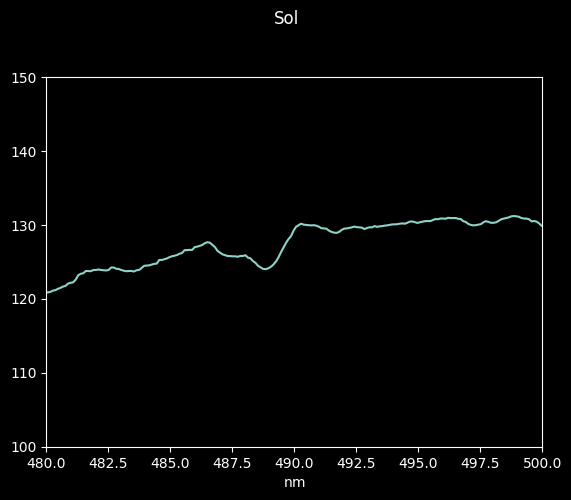

In [18]:
plt.suptitle("Sol", y=1.02)
plt.plot(wavelengths4, spectrum4)
plt.axis([480,500,100,150])

Podemos utilizar modelos de astropy para construir un modelo de línea de absorción, que consta de un nivel continuo y una gaussiana negativa para representar la característica de absorción.

In [82]:
absorption_model_guess = Linear1D(slope=0, intercept=175) + Gaussian1D(amplitude=-25, mean=486, stddev=3)
absorption_model_guess2 = Linear1D(slope=0, intercept=135) + Gaussian1D(amplitude=-25, mean=519.5, stddev=1)
absorption_model_guess3 = Linear1D(slope=0, intercept=125) + Gaussian1D(amplitude=-25, mean=533, stddev=2)
absorption_model_guess4 = Linear1D(slope=0, intercept=129) + Gaussian1D(amplitude=-5, mean=489 ,stddev=0.5)


Podemos sobregraficar nuestro modelo supuesto: no es correcto, pero está en el lugar correcto.

(np.float64(470.0), np.float64(510.0), np.float64(140.0), np.float64(190.0))

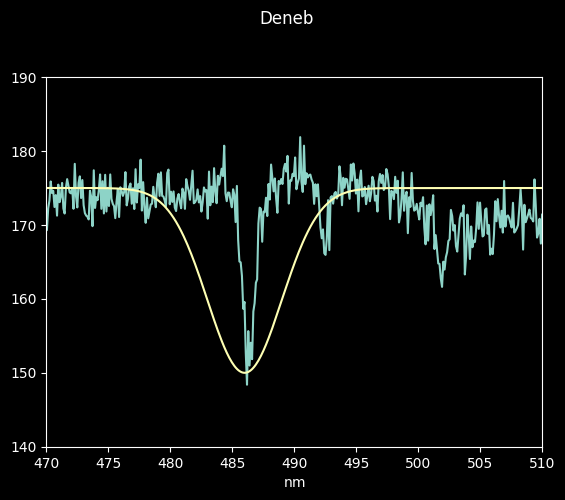

In [40]:
plt.plot(wavelengths2, spectrum2)
plt.suptitle("Deneb", y=1.02)
plt.plot(wavelengths2, absorption_model_guess(wavelengths2.value))
plt.axis([470,510,140,190])


(np.float64(510.0), np.float64(530.0), np.float64(100.0), np.float64(170.0))

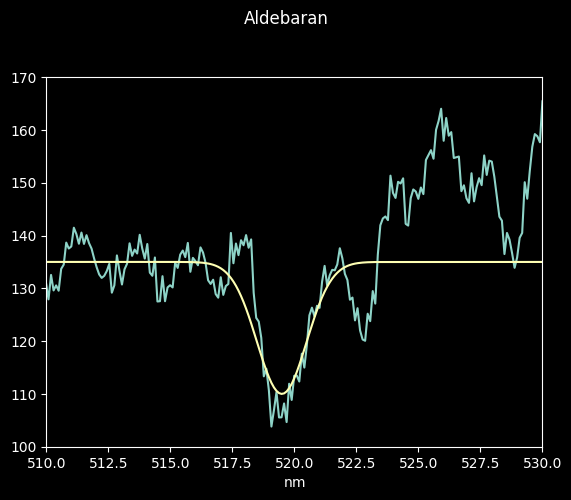

In [57]:
plt.plot(wavelengths1, spectrum1)
plt.suptitle("Aldebaran", y=1.02)
plt.plot(wavelengths1, absorption_model_guess2(wavelengths1.value))
plt.axis([510,530,100,170])

(np.float64(520.0), np.float64(550.0), np.float64(90.0), np.float64(150.0))

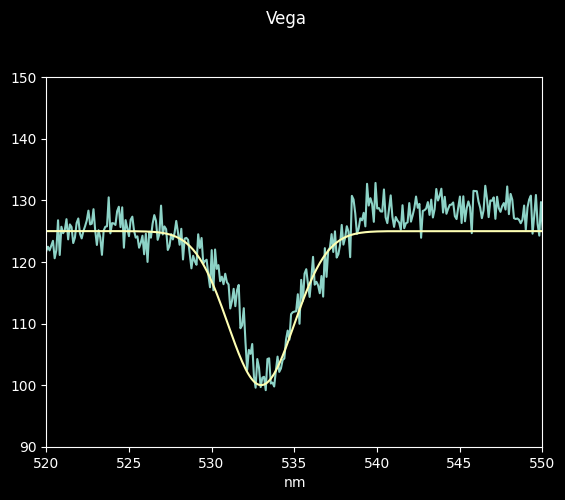

In [65]:
plt.plot(wavelengths3, spectrum3)
plt.suptitle("Vega", y=1.02)
plt.plot(wavelengths3, absorption_model_guess3(wavelengths3.value))
plt.axis([520,550,90,150])

(np.float64(480.0), np.float64(500.0), np.float64(100.0), np.float64(150.0))

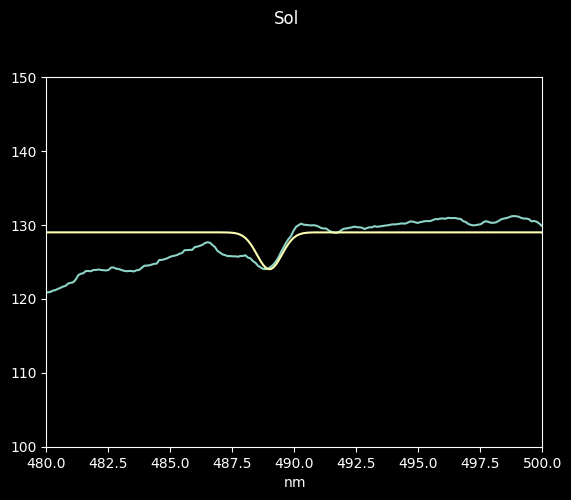

In [83]:
plt.plot(wavelengths4, spectrum4)
plt.suptitle("Sol", y=1.02)
plt.plot(wavelengths4, absorption_model_guess4(wavelengths4.value))
plt.axis([480,500,100,150])

El ajustador de mínimos cuadrados de Levenberg-Marquardt se puede utilizar para encontrar el ajuste óptimo a nuestros datos dado el valor inicial.

In [95]:
lmfitter = LevMarLSQFitter()
selection = (wavelengths2 > 470*u.nm) & (wavelengths2 < 500*u.nm) 
fitted_absorption_model = lmfitter(model=absorption_model_guess, x=wavelengths2.value[selection], y=spectrum2[selection])

selection1 = (wavelengths1 > 510*u.nm) & (wavelengths1 < 530*u.nm) 
fitted_absorption_model1 = lmfitter(model=absorption_model_guess2, x=wavelengths1.value[selection1], y=spectrum1[selection1])

selection3 = (wavelengths3 > 520*u.nm) & (wavelengths3 < 550*u.nm) 
fitted_absorption_model3 = lmfitter(model=absorption_model_guess3, x=wavelengths3.value[selection3], y=spectrum3[selection3])

selection4 = (wavelengths4 > 480*u.nm) & (wavelengths4 < 500*u.nm) 
fitted_absorption_model4 = lmfitter(model=absorption_model_guess4, x=wavelengths4.value[selection4], y=spectrum4[selection4])



(np.float64(470.0), np.float64(510.0), np.float64(140.0), np.float64(190.0))

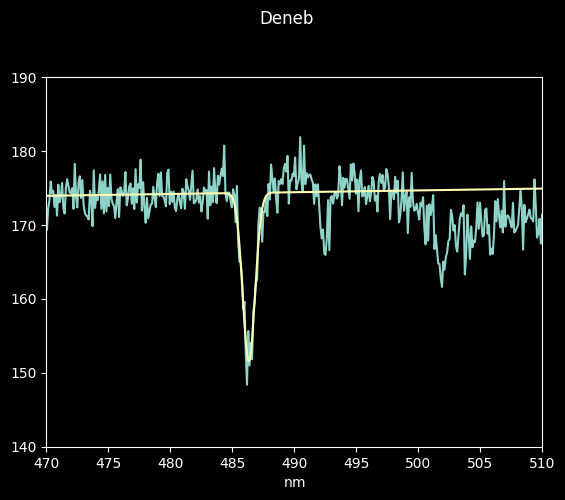

In [92]:
plt.plot(wavelengths2, spectrum2)
plt.suptitle("Deneb", y=1.02)
plt.plot(wavelengths2, fitted_absorption_model(wavelengths2.value))
plt.axis([470,510,140,190])

(np.float64(510.0), np.float64(530.0), np.float64(100.0), np.float64(170.0))

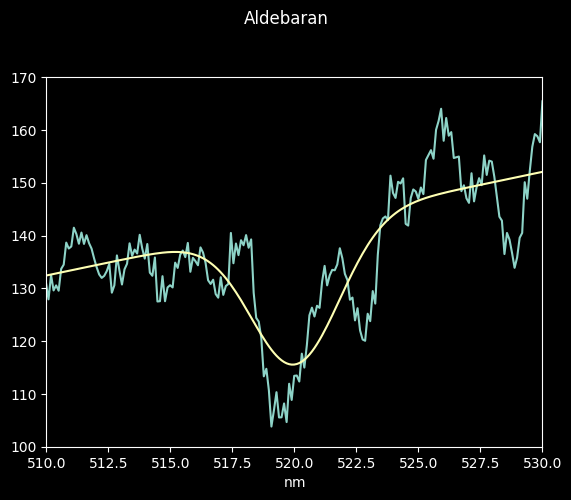

In [96]:
plt.plot(wavelengths1, spectrum1)
plt.suptitle("Aldebaran", y=1.02)
plt.plot(wavelengths1, fitted_absorption_model1(wavelengths1.value))
plt.axis([510,530,100,170])

(np.float64(520.0), np.float64(550.0), np.float64(90.0), np.float64(150.0))

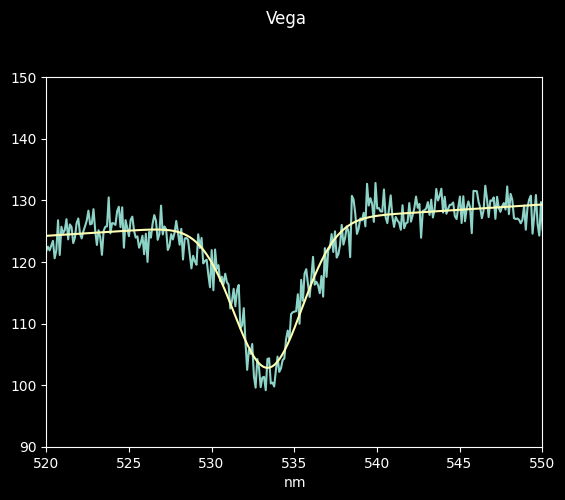

In [97]:
plt.plot(wavelengths3, spectrum3)
plt.suptitle("Vega", y=1.02)
plt.plot(wavelengths3, fitted_absorption_model3(wavelengths3.value))
plt.axis([520,550,90,150])

(np.float64(480.0), np.float64(500.0), np.float64(100.0), np.float64(150.0))

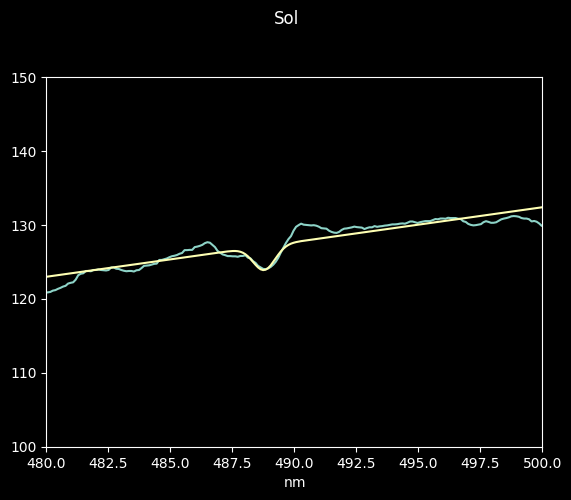

In [98]:
plt.plot(wavelengths4, spectrum4)
plt.suptitle("Sol", y=1.02)
plt.plot(wavelengths4, fitted_absorption_model4(wavelengths4.value))
plt.axis([480,500,100,150])

Ahora podemos separar los dos componentes, el modelo continuo y el modelo de línea de absorción:

In [99]:
continuum_fit, absorption_fit = fitted_absorption_model

continuum_fit1, absorption_fi1 = fitted_absorption_model1

continuum_fit3, absorption_fi3 = fitted_absorption_model3

continuum_fit4, absorption_fi4 = fitted_absorption_model4

Si graficamos los datos menos el modelo de línea de absorción, obtenemos un bonito "continuo sin líneas":

(np.float64(470.0), np.float64(510.0), np.float64(140.0), np.float64(190.0))

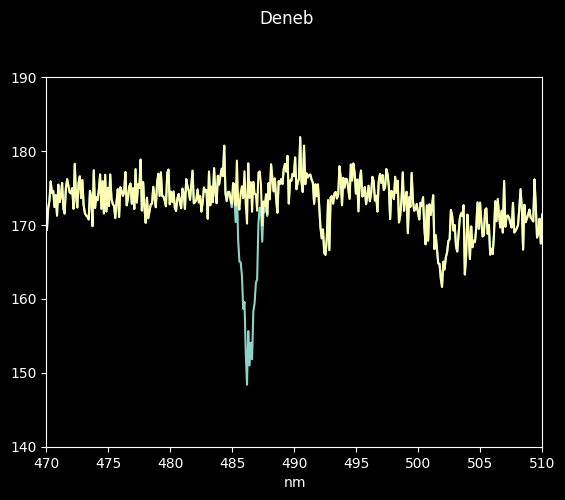

In [35]:
plt.plot(wavelengths2, spectrum2)
plt.suptitle("Deneb", y=1.02)
plt.plot(wavelengths2, spectrum2 - absorption_fit(wavelengths2.value))
plt.axis([470,510,140,190])

(np.float64(510.0), np.float64(530.0), np.float64(100.0), np.float64(170.0))

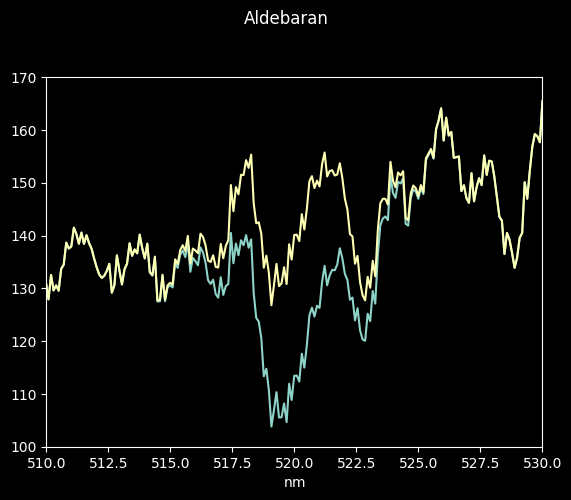

In [ ]:
plt.plot(wavelengths1, spectrum1)
plt.suptitle("Aldebaran", y=1.02)
plt.plot(wavelengths1, spectrum1 - absorption_fi1(wavelengths1.value))
plt.axis([510,530,100,170])

(np.float64(520.0), np.float64(550.0), np.float64(90.0), np.float64(150.0))

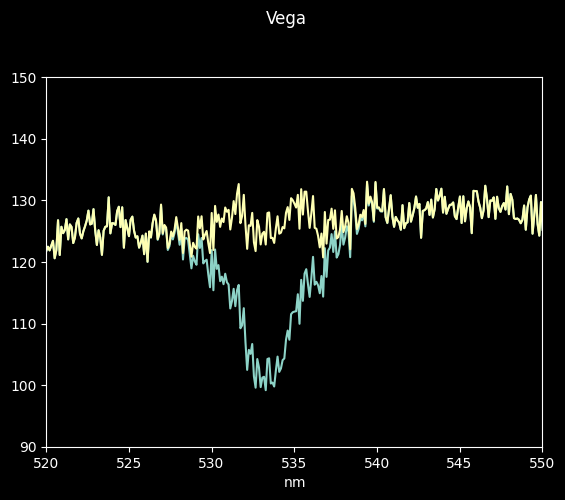

In [101]:
plt.plot(wavelengths3, spectrum3)
plt.suptitle("Vega", y=1.02)
plt.plot(wavelengths3, spectrum3 - absorption_fi3(wavelengths3.value))
plt.axis([520,550,90,150])

(np.float64(480.0), np.float64(500.0), np.float64(100.0), np.float64(150.0))

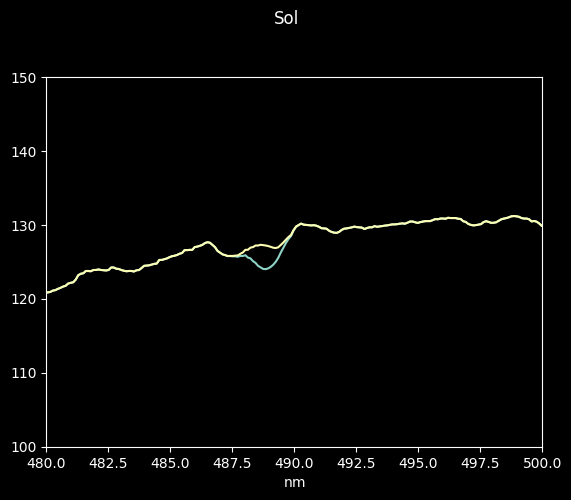

In [102]:
plt.plot(wavelengths4, spectrum4)
plt.suptitle("Sol", y=1.02)
plt.plot(wavelengths4, spectrum4 - absorption_fi4(wavelengths4.value))
plt.axis([480,500,100,150])

El [Ancho Equivalente](https://en.wikipedia.org/wiki/Equivalent_width) de una línea de absorción espectral se define como el ancho de una característica que tiene la misma integral que la línea de absorción, pero que se extiende desde el nivel del continuo hasta cero.

Podemos calcular esto con nuestro modelo, suponiendo que nuestro continuo es plano (con pendiente cero):

In [109]:
EQW =  -absorption_fit(wavelengths2.value[selection]).sum() / continuum_fit.intercept * u.nm
EQW1 =  -absorption_fi1(wavelengths1.value[selection1]).sum() / continuum_fit1.intercept * u.nm
EQW3 =  -absorption_fi3(wavelengths3.value[selection3]).sum() / continuum_fit3.intercept * u.nm
EQW4 =  -absorption_fi4(wavelengths4.value[selection4]).sum() / continuum_fit4.intercept * u.nm

EQW4

<Quantity -0.33982362 nm>

Utilizando la gaussinana podemos indentificar con la media la linea de absorcion que estamos buscando. 

In [116]:
print(absorption_fit)
print(absorption_fi1)
print(absorption_fi3)
print(absorption_fi4)


Model: Gaussian1D
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
         amplitude             mean               stddev      
    ------------------- ------------------ -------------------
    -22.814982851048583 486.34294503605406 0.49692951207741753
Model: Gaussian1D
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
        amplitude            mean             stddev      
    ------------------ ---------------- ------------------
    -26.68988202653498 520.053526403763 1.7752819283976242
Model: Gaussian1D
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
         amplitude             mean             stddev      
    ------------------- ----------------- ------------------
    -23.696576872990057 533.4135504849896 2.0581355320621806
Model: Gaussian1D
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
         amplitude             mean               stddev      
    ------------------- ------------------ -------------------
    -3.22

Hemos identificado la línea como H-beta, por lo que ahora podemos medir algunas de sus propiedades (Para Deneb)

Para  las otras estrellas 
- Aldebaran  b_1 elemnto Mg  518.362 
- Vega  E_2 elemento Fe 527.039 
- Sol  F(H_\beta) H 486.134 
Tomado de https://en.wikipedia.org/wiki/Astronomical_spectroscopy

In [117]:
air_wavelength_hbeta = 486.135*u.nm # wikipedia https://en.wikipedia.org/wiki/Balmer_series
air_wavelength_hbetasun = 486.134*u.nm
air_wavelength_b1= 518.362*u.nm
air_wavelength_E2 = 521.039*u.nm

El desplazamiento Doppler nos indicará la velocidad de la estrella. Cabe destacar que esta velocidad se obtiene en el sistema topocéntrico, es decir, en el sistema de referencia en reposo del observatorio. Si supiéramos con precisión cuándo y dónde se tomaron estas observaciones, podríamos convertir esta velocidad a los sistemas heliocéntrico o LSR con las herramientas de astropy (https://docs.astropy.org/en/stable/coordinates/velocities.html).

Primero, hacemos el cálculo manualmente, siguiendo la definición óptica
$$v_{opt} = c \frac{\lambda-\lambda_0}{\lambda} $$

In [30]:
doppler_velocity = (absorption_fit.mean*u.nm - air_wavelength_hbeta) / (air_wavelength_hbeta) * constants.c
doppler_velocity.to(u.km/u.s)

<Quantity 128.23671097 km / s>

Podemos hacer lo mismo usando [equivalencias de astropía](https://docs.astropy.org/en/stable/units/equivalencies.html#spectral-doppler-equivalencies):

In [31]:
doppler_velocity = (absorption_fit.mean*u.nm).to(u.km/u.s, u.doppler_optical(air_wavelength_hbeta))
doppler_velocity

<Quantity 128.23671097 km / s>

También podemos calcular el ancho de línea a partir de nuestro ajuste:

In [32]:
linewidth_kms = (absorption_fit.stddev*u.nm) / air_wavelength_hbeta * constants.c.to(u.km/u.s)
linewidth_kms

<Quantity 306.44927824 km / s>

¡Listo! Has extraído y calibrado la longitud de onda de un espectro.

El siguiente paso, más complejo, es la calibración del flujo, pero lo haremos en un tutorial posterior porque necesitamos un conjunto de datos diferente; este no incluía los datos necesarios para la calibración del flujo (aunque pudimos calibrar aproximadamente el espectro utilizando una magnitud conocida en la banda observada para Deneb).